<a href="https://colab.research.google.com/github/purnimamarasinghe2005-lgtm/BI-and-Data-Mining/blob/main/Copy_of_diabetes_readmission_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting 30-Day Hospital Readmissions for Diabetic Patients: A Business Intelligence Approach

**Module:** Business Intelligence and Data Mining (UFCFMM)  
**Assessment:** Portfolio – Group Project Portfolio  
**Students:** Sadeep Madushan, Sin
**Date:** 02 April 2026

A business intelligence model in predicting 30-day hospital readmission of diabetic patients.

## 1. Business Problem Characterization.

Readmission of patients within 30 days of hospital stay is another issue for health care providers, which has become a major operational and economic problem. Soaring readmission rates not only add to the cost of treatment but also decrease the number of free beds and can have an overall adverse impact on performance ratings of hospitals as regarded by insurance companies and regulatory organizations. Hospitals with high readmission rates in a particular healthcare system are fined and risk their reputation.

Operationally speaking, the administrators of the hospital would need proactive intelligence to help them know about the high-risk patients ahead of the discharge to ensure that specific interventions are done towards them. The interventions can be improved discharge planning, reviewing of medication, making of follow-up calls after discharge, or even monitoring of them at home.

Diabetes is a chronic illness that is highly common in the world and which is attributed to a high rate of hospitalization and complications. The non-adherence to medication, poor glycemic control, and comorbidities may cause excessive risks of readmission. Hence, data mining in healthcare business intelligence can have a useful application in the prediction of 30-day readmission risk among patients with diabetes.

This project also seeks to come up with a predictive classification model able to determine whether a patient with diabetes is at risk of readmission within 30 days or not. The task is not to create an accurate model alone but to convert predictive outcomes into actionable information that aids in terms of hospital resource allocation and operational decision-making.

## 2. Dataset Justification

The research employs the publicly accessible UCI Machine Learning Repository of the dataset titled Diabetes 130-US hospitals in order to address this issue. The data set has more than 101,000 hospital encounters between 1999 and 2008 in 130 hospitals in the United States.

The reason why this dataset is suitable to the project is that
- It has a specific readmission outcome variable.
- It contains the demographic, diagnostic, and utilization of hospital aspects that are applicable in prediction.
- It is real-life anonymized healthcare data, which can be used in business intelligence modeling.

Nonetheless, restrictions have to be taken into account. The dataset targets specifically diabetic patients and also represents past US healthcare practices, and this may influence the generalizability. These will be the limiting factors that will be taken seriously in interpreting results.

## 3. Project Objectives

The targeted goals of this project are:

- To investigate and learn the trends related to 30-day readmissions.
- In order to construct and compare several classification models.
- To measure model performance based on the right healthcare metrics.
- To present the results of the analytical work in the form of practical strategic recommendations.
- To critically evaluate predicted healthcare analytics ethical, privacy, and security impacts.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, precision_recall_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [71]:
data_path = "/content/sample_data/diabetic_data.csv"
ids_path  = "/content/sample_data/IDS_mapping.csv"

df_raw = pd.read_csv(data_path)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [72]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Target Definition (30-day readmission)

The original `readmitted` variable has three values: `<30`, `>30`, and `NO`.  
For decision support, we define a binary target:

- **1:** readmitted within 30 days (`<30`)
- **0:** not readmitted within 30 days (`>30` or `NO`)

This makes the output directly actionable for hospital intervention planning.

In [73]:
df = df_raw.copy()

print(df["readmitted"].value_counts())

df["readmit_30"] = (df["readmitted"] == "<30").astype(int)
print("\nBinary target counts:")
print(df["readmit_30"].value_counts())
print("\nBinary positive rate:", df["readmit_30"].mean())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Binary target counts:
readmit_30
0    90409
1    11357
Name: count, dtype: int64

Binary positive rate: 0.11159915885462728


## Missing values profiling

This dataset uses `?` to represent unknown values in several categorical columns.  
We first quantify `?` and then convert it to `NaN` for consistent preprocessing.

In [74]:
missing_q = (df == "?").sum().sort_values(ascending=False)
missing_q.head(15)

,0
weight,98569
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
admission_type_id,0
discharge_disposition_id,0
patient_nbr,0


In [75]:
df = df.replace("?", np.nan)
missing_pct = df.isna().mean().sort_values(ascending=False)
missing_pct.head(15)

,0
weight,0.968585
max_glu_serum,0.947468
A1Cresult,0.832773
medical_specialty,0.490822
payer_code,0.395574
race,0.022336
diag_3,0.013983
diag_2,0.003518
diag_1,0.000206
patient_nbr,0.000000


## Data Cleaning and Feature Selection

The dataset contains several attributes with very high missing rates. Columns with extremely high missingness provide little reliable information and may introduce noise into the model. Therefore, we apply the following decisions:

• **weight** (96.8% missing) → removed due to insufficient data  
• **max_glu_serum** (94.7% missing) → removed because most entries are unknown  
• **A1Cresult** (83.2% missing) → removed due to excessive missing values  
• **payer_code** (39.5% missing) → removed as the variable has large missingness and limited predictive value  

The column **medical_specialty** has approximately 49% missing values. However, it may still contain useful clinical information, so missing values will be treated as a separate category (“Unknown”).

Additionally, **encounter_id** is a unique identifier and does not contribute to prediction, therefore it is removed.

These decisions improve data quality while preserving clinically relevant variables for analysis.

In [76]:
# Copy dataset
df_clean = df.copy()

# Drop columns with extremely high missing values
drop_cols = ["weight", "max_glu_serum", "A1Cresult", "payer_code", "encounter_id"]

df_clean = df_clean.drop(columns=drop_cols)

# Check remaining shape
print("New shape:", df_clean.shape)

df_clean.head()

New shape: (101766, 46)


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmit_30
0,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,...,No,No,No,No,No,No,No,No,NO,0
1,55629189,Caucasian,Female,[10-20),1,1,7,3,NaN,59,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,11,...,No,No,No,No,No,No,No,Yes,NO,0
3,82442376,Caucasian,Male,[30-40),1,1,7,2,NaN,44,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,42519267,Caucasian,Male,[40-50),1,1,7,1,NaN,51,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


## Handling Remaining Missing Values

Remaining missing values are relatively small.

• **race** missing values will be replaced with "Unknown"  
• **medical_specialty** missing values will be replaced with "Unknown"  
• **diag_1, diag_2, diag_3** represent diagnosis codes and missing values will be replaced with "Unknown"

This approach preserves useful information while avoiding unnecessary row removal.

In [77]:
fill_unknown_cols = ["race", "medical_specialty", "diag_1", "diag_2", "diag_3"]

for col in fill_unknown_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("Unknown")

# Check missing values again
df_clean.isna().sum().sort_values(ascending=False).head(10)

,0
patient_nbr,0
race,0
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
medical_specialty,0
num_lab_procedures,0


In [78]:
df_clean["readmit_30"] = (df_clean["readmitted"] == "<30").astype(int)

df_clean["readmit_30"].value_counts()

,count
readmit_30,
0,90409
1,11357


In [79]:
df_clean = df_clean.drop(columns=["readmitted"])

In [80]:
df_clean.describe()

,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmit_30
count,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,0.111599
std,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,0.314874
min,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000
50%,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000
75%,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,0.000000
max,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000


In [81]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   patient_nbr               101766 non-null  int64 
 1   race                      101766 non-null  object
 2   gender                    101766 non-null  object
 3   age                       101766 non-null  object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   medical_specialty         101766 non-null  object
 9   num_lab_procedures        101766 non-null  int64 
 10  num_procedures            101766 non-null  int64 
 11  num_medications           101766 non-null  int64 
 12  number_outpatient         101766 non-null  int64 
 13  number_emergency          101766 non-null  int64 
 14  numb

In [82]:
df_clean.shape

(101766, 45)

In [83]:
df_clean.head()

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmit_30
0,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,...,No,No,No,No,No,No,No,No,No,0
1,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,59,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,11,...,No,No,No,No,No,No,No,No,Yes,0
3,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,44,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,51,...,No,Steady,No,No,No,No,No,Ch,Yes,0


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is conducted to understand the structure of the dataset and identify patterns related to hospital readmission. Visualisations are used to explore relationships between patient characteristics, hospital utilisation metrics, and the probability of readmission within 30 days.

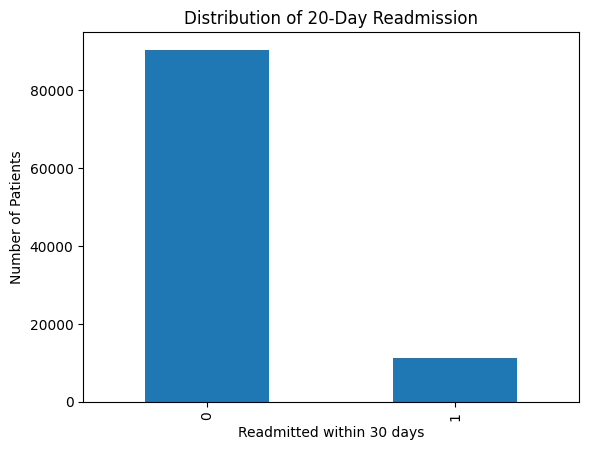

In [84]:
df_clean["readmit_30"].value_counts().plot(kind="bar")

plt.title("Distribution of 20-Day Readmission")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of Patients")

plt.show()

### Insight
The dataset shows a class imbalance where most patients are not readmitted within 30 days. This imbalance must be considered during model evaluation because accuracy alone may be misleading.

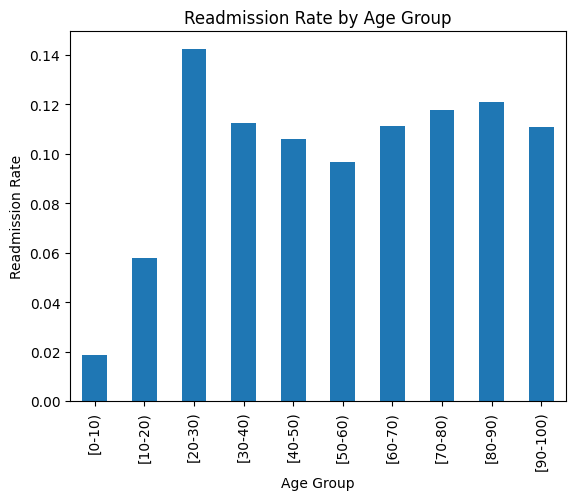

In [85]:
age_readmit = df_clean.groupby("age")["readmit_30"].mean()

age_readmit.plot(kind="bar")

plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate")

plt.show()

### Insight
Older patient groups tend to have higher readmission rates. This suggests that elderly diabetic patients may require stronger discharge planning and follow-up care to reduce hospital readmissions.

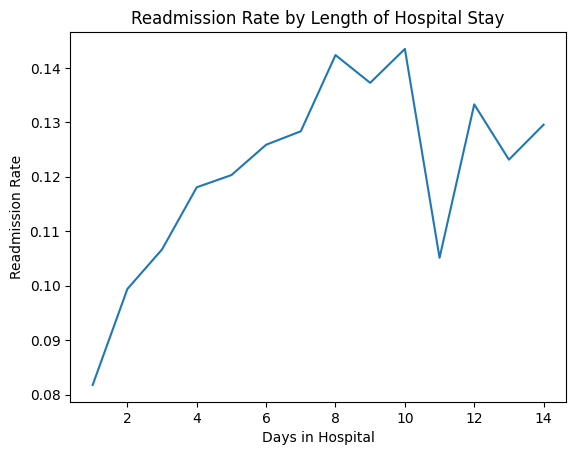

In [86]:
stay_readmit = df_clean.groupby("time_in_hospital")["readmit_30"].mean()

stay_readmit.plot(kind="line")

plt.title("Readmission Rate by Length of Hospital Stay")
plt.xlabel("Days in Hospital")
plt.ylabel("Readmission Rate")

plt.show()

### Insight
Patients who stay longer in the hospital tend to show a higher probability of readmission, which may indicate more severe medical conditions requiring additional monitoring after discharge.

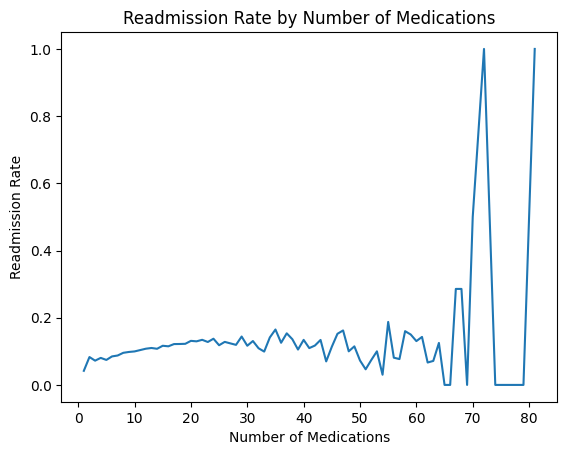

In [87]:
med_readmit = df_clean.groupby("num_medications")["readmit_30"].mean()

med_readmit.plot(kind="line")

plt.title("Readmission Rate by Number of Medications")
plt.xlabel("Number of Medications")
plt.ylabel("Readmission Rate")

plt.show()

### Insight
Higher medication counts are associated with increased readmission risk, possibly reflecting complex treatment plans or severe medical conditions.

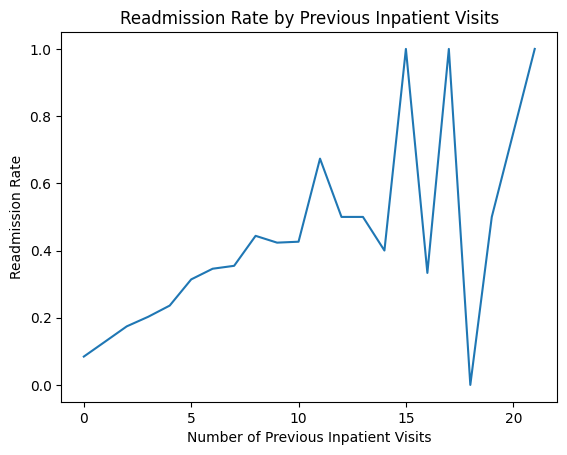

In [88]:
inpatient_readmit = df_clean.groupby("number_inpatient")["readmit_30"].mean()

inpatient_readmit.plot(kind="line")

plt.title("Readmission Rate by Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Readmission Rate")

plt.show()

### Insight
Patients with multiple previous inpatient visits show significantly higher readmission rates, indicating that past hospital utilisation is a strong predictor of future readmissions.

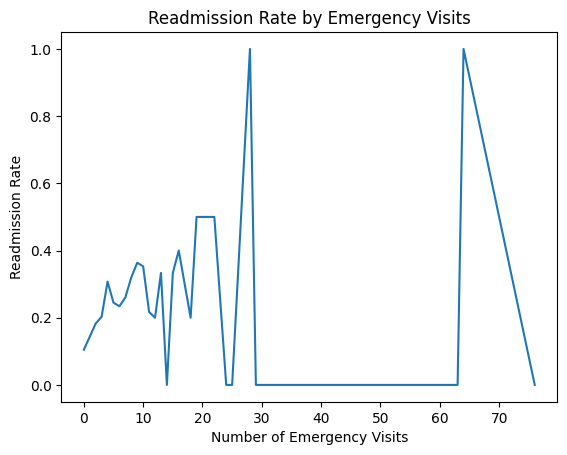

In [89]:
emergency_readmit = df_clean.groupby("number_emergency")["readmit_30"].mean()

emergency_readmit.plot(kind="line")

plt.title("Readmission Rate by Emergency Visits")
plt.xlabel("Number of Emergency Visits")
plt.ylabel("Readmission Rate")

plt.show()

### Insight
Frequent emergency visits are associated with higher readmission rates, suggesting that patients with unstable health conditions may require more structured follow-up care.

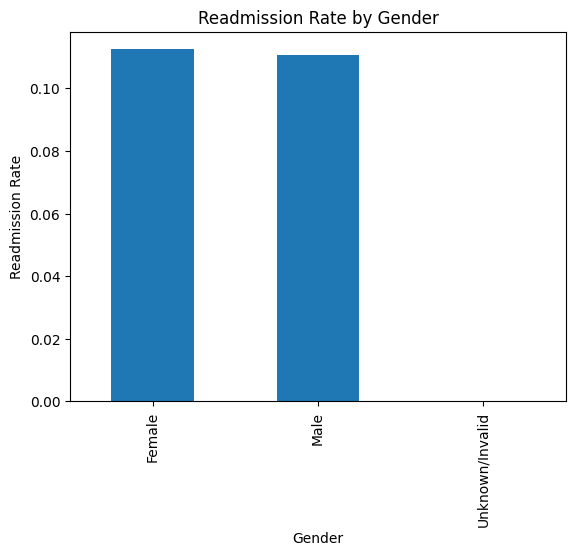

In [90]:
gender_readmit = df_clean.groupby("gender")["readmit_30"].mean()

gender_readmit.plot(kind="bar")

plt.title("Readmission Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Readmission Rate")

plt.show()

### Insight
Readmission rates between genders appear relatively similar, suggesting that gender alone may not be a strong predictor of readmission risk.

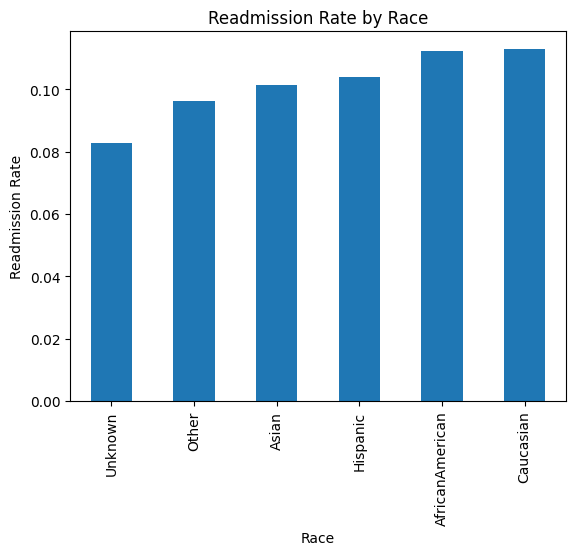

In [91]:
race_readmit = df_clean.groupby("race")["readmit_30"].mean().sort_values()

race_readmit.plot(kind="bar")

plt.title("Readmission Rate by Race")
plt.xlabel("Race")
plt.ylabel("Readmission Rate")

plt.show()

### Insight
Differences in readmission rates across racial groups highlight the importance of examining fairness and potential bias in predictive healthcare models.